# Pseudo-Spectral Chebyshev Trajectory Fitting

This notebook fits a smooth planar trajectory to regularly spaced 2D samples with a factor graph. The unknown is a $2 \times N$ matrix whose columns are trajectory positions at second-kind Chebyshev (Chebyshev--Lobatto) points. `VectorEvaluationFactorChebyshev2` interpolates those unknown node values at every sample parameter.

The trajectory comes from the `VERTEX2` records in GTSAM's `examples/Data/example.graph` dataset. We load those records through GTSAM's `dataset.h` machinery rather than parsing the file in Python.

GTSAM Copyright 2010-2026, Georgia Tech Research Corporation,
Atlanta, Georgia 30332-0415
All Rights Reserved

Authors: Frank Dellaert, et al. (see THANKS for the full author list)

See LICENSE for the license information

<a href="https://colab.research.google.com/github/borglab/gtsam/blob/develop/python/gtsam/examples/PseudoSpectralChebyshevExample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
# Install GTSAM from pip if running in Google Colab.
try:
    import google.colab
    %pip install --quiet gtsam-develop
except ImportError:
    pass  # Not in Colab

In [20]:
import matplotlib.pyplot as plt
import numpy as np

import gtsam

np.set_printoptions(precision=3, suppress=True)

## Load the regularly spaced 2D trajectory

`findExampleDataFile` locates the packaged dataset, and `load2D` invokes GTSAM's `dataset.h` loader. The returned `Values` contains a `Pose2` at each untagged key from a `VERTEX2` record, as well as tagged landmark values that we exclude. We retain each pose's translation and use vertex order as a regularly spaced trajectory parameter on $[0,1]$. The edge factors in the file are not needed for this curve-fitting example.

In [21]:
data_file = gtsam.findExampleDataFile("example.graph")
_, poses = gtsam.load2D(data_file)

pose_keys = sorted(
    key for key in poses.keys() if gtsam.symbolChr(key) == 0
)
sample_points = np.array(
    [poses.atPose2(key).translation() for key in pose_keys]
)
sample_parameters = np.linspace(0.0, 1.0, len(sample_points))

print(f"Loaded {len(sample_points)} VERTEX2 samples from {data_file}")
print(f"First point: {sample_points[0]}")
print(f"Last point:  {sample_points[-1]}")

Loaded 95 VERTEX2 samples from /Users/dellaert/.local/lib/python3.12/site-packages/gtsam/Data/example.graph
First point: [-0.138  0.342]
Last point:  [53.529  8.305]


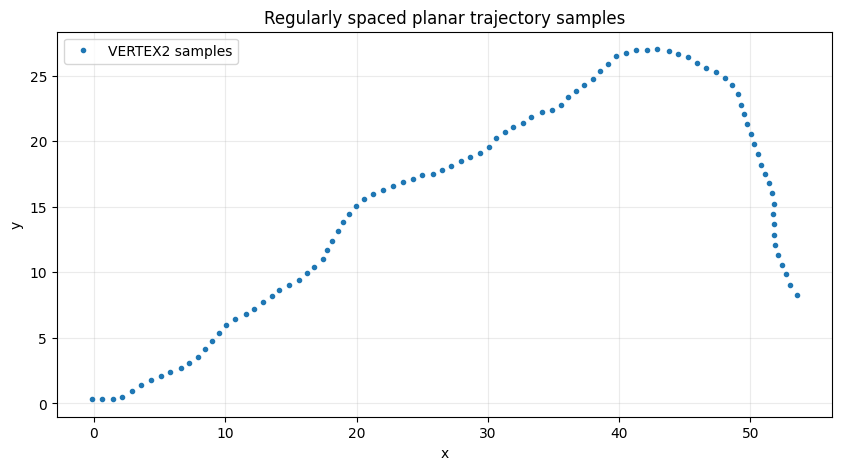

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sample_points[:, 0], sample_points[:, 1], ".", color="tab:blue", label="VERTEX2 samples",)
ax.set_title("Regularly spaced planar trajectory samples")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal", adjustable="datalim")
ax.grid(alpha=0.25)
ax.legend();

## Build the factor graph

Let $P \in \mathbb{R}^{2 \times N}$ contain the unknown 2D positions at the $N$ Chebyshev points. For sample parameter $t_i$, `Chebyshev2` computes barycentric weights $w(t_i)$ and predicts

$$\hat p_i = P\,w(t_i).$$

Every `VectorEvaluationFactorChebyshev2` adds the residual $\hat p_i-p_i$ to the same matrix variable. Thus the graph solves the least-squares problem over all regular samples. `N` is the number of pseudo-spectral nodes, so the interpolating polynomial has degree at most $N-1$.

In [23]:
N = 16
DIMENSION = 2
LOWER = 0.0
UPPER = 1.0
NODE_KEY = gtsam.symbol("P", 0)

graph = gtsam.NonlinearFactorGraph()
measurement_model = gtsam.noiseModel.Isotropic.Sigma(DIMENSION, 1.0)

for parameter, point in zip(sample_parameters, sample_points):
    graph.add(
        gtsam.VectorEvaluationFactorChebyshev2(
            NODE_KEY,
            point,
            measurement_model,
            DIMENSION,
            N,
            parameter,
            LOWER,
            UPPER,
        )
    )

print(f"Graph: {graph.size()} sample factors, one {DIMENSION}x{N} variable")

Graph: 95 sample factors, one 2x16 variable


## Optimize the Chebyshev node values

For a useful initial visualization, we linearly interpolate the regular samples at the fixed Chebyshev parameters. The factor model is linear in $P$, so the initial value does not affect the least-squares optimum and Gauss--Newton reaches it in one linear step.

In [24]:
chebyshev_parameters = gtsam.Chebyshev2.Points(N, LOWER, UPPER)
initial_node_matrix = np.vstack(
    [
        np.interp(chebyshev_parameters, sample_parameters, sample_points[:, axis])
        for axis in range(DIMENSION)
    ]
)

initial = gtsam.Values()
initial.insert(NODE_KEY, initial_node_matrix)

initial_error = graph.error(initial)
result = gtsam.GaussNewtonOptimizer(graph, initial).optimize()
node_matrix = result.atMatrix(NODE_KEY)  # 2 x N
final_error = graph.error(result)

print(f"Initial graph error: {initial_error:.6f}")
print(f"Final graph error:   {final_error:.6f}")
print(f"Optimized node matrix shape: {node_matrix.shape}")

Initial graph error: 4.788934
Final graph error:   2.309378
Optimized node matrix shape: (2, 16)


## Interpolate the fitted trajectory

The optimized columns of `node_matrix` are values at the red Chebyshev points, not polynomial coefficients. A dense `WeightMatrix` interpolates those values to produce the continuous trajectory.

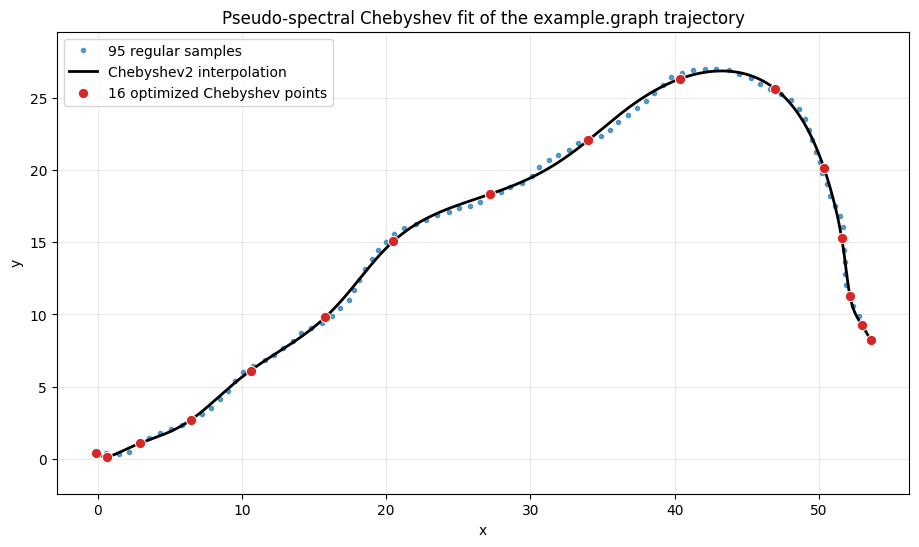

In [25]:
dense_parameters = np.linspace(LOWER, UPPER, 1000)
dense_weight_matrix = gtsam.Chebyshev2.WeightMatrix(
    N, dense_parameters, LOWER, UPPER
)
dense_points = dense_weight_matrix @ node_matrix.T
chebyshev_points = node_matrix.T

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(sample_points[:, 0], sample_points[:, 1], ".", color="tab:blue", alpha=0.7, label=f"{len(sample_points)} regular samples")
ax.plot(dense_points[:, 0], dense_points[:, 1], color="black", linewidth=2, label="Chebyshev2 interpolation")
ax.scatter(chebyshev_points[:, 0], chebyshev_points[:, 1], s=55, color="tab:red", edgecolor="white", linewidth=0.7, zorder=3, label=f"{N} optimized Chebyshev points")
ax.set_title("Pseudo-spectral Chebyshev fit of the example.graph trajectory")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal", adjustable="datalim")
ax.grid(alpha=0.25)
ax.legend();

## What the factor graph buys us

The graph representation makes it straightforward for the same Chebyshev node matrix to participate in additional factors, such as endpoint observations, derivative constraints, component-specific measurements, or joint estimation with other variables.

## Optimize the same parameters with gradient descent

We can also optimize the $2 \times N$ Chebyshev node matrix directly, using gradient descent. We'll leave it there whether this is a good idea or not, :-).

Let $W \in \mathbb{R}^{M \times N}$ contain the barycentric interpolation weights at the $M$ sample parameters, let $P \in \mathbb{R}^{2 \times N}$ contain the Chebyshev node positions, and let $Y \in \mathbb{R}^{M \times 2}$ contain the data. We define the mean loss per 2D sample as

$$\mathcal{L}(P) = \frac{1}{2M}\left\|W P^T - Y\right\|_F^2,$$

with gradient

$$\nabla_P \mathcal{L}(P) = \frac{1}{M}\left(WP^T-Y\right)^T W.$$

The node positions are the only parameters; the regular trajectory samples are fixed data.

In [26]:
sample_weight_matrix = gtsam.Chebyshev2.WeightMatrix(
    N, sample_parameters, LOWER, UPPER
)

def pseudospectral_loss(node_parameters, samples, weight_matrix):
    """Mean squared interpolation loss per 2D sample."""
    residuals = weight_matrix @ node_parameters.T - samples
    return 0.5 * np.mean(np.sum(residuals**2, axis=1))


def pseudospectral_loss_gradient(node_parameters, samples, weight_matrix):
    """Gradient of pseudospectral_loss with respect to the node matrix."""
    residuals = weight_matrix @ node_parameters.T - samples
    return residuals.T @ weight_matrix / len(samples)

Starting from zero node positions, each gradient-descent step applies $P \leftarrow P - \eta\,\nabla_P\mathcal{L}$. We choose a conservative fixed learning rate from the Frobenius norm of $W$, avoiding any matrix factorization.

In [27]:
NUM_STEPS = 1200
learning_rate = (
    0.9 * len(sample_points) / np.sum(sample_weight_matrix**2)
)

gd_node_matrix = np.zeros((DIMENSION, N))
loss_history = []

for _ in range(NUM_STEPS):
    loss_history.append(
        pseudospectral_loss(
            gd_node_matrix, sample_points, sample_weight_matrix
        )
    )
    gradient = pseudospectral_loss_gradient(
        gd_node_matrix, sample_points, sample_weight_matrix
    )
    gd_node_matrix -= learning_rate * gradient

loss_history.append(
    pseudospectral_loss(gd_node_matrix, sample_points, sample_weight_matrix)
)

print(f"Learning rate: {learning_rate:.3f}")
print(f"Initial loss: {loss_history[0]:.6f}")
print(f"Final loss:   {loss_history[-1]:.6f}")

Learning rate: 0.903
Initial loss: 740.829278
Final loss:   0.024309


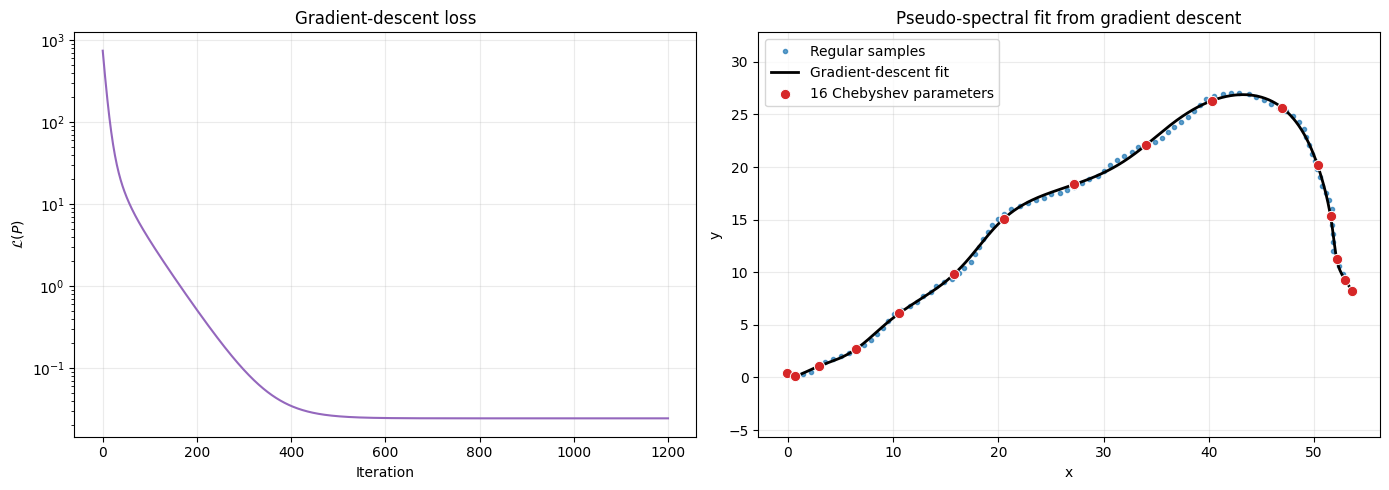

In [28]:
gd_dense_points = dense_weight_matrix @ gd_node_matrix.T
gd_chebyshev_points = gd_node_matrix.T

fig, (loss_ax, trajectory_ax) = plt.subplots(1, 2, figsize=(14, 5))

loss_ax.semilogy(loss_history, color="tab:purple")
loss_ax.set_title("Gradient-descent loss")
loss_ax.set_xlabel("Iteration")
loss_ax.set_ylabel(r"$\mathcal{L}(P)$")
loss_ax.grid(alpha=0.25)

trajectory_ax.plot(sample_points[:, 0], sample_points[:, 1], ".",color="tab:blue", alpha=0.7, label="Regular samples")
trajectory_ax.plot(gd_dense_points[:, 0], gd_dense_points[:, 1],color="black", linewidth=2, label="Gradient-descent fit")
trajectory_ax.scatter(gd_chebyshev_points[:, 0], gd_chebyshev_points[:, 1],s=55, color="tab:red", edgecolor="white", linewidth=0.7,zorder=3, label=f"{N} Chebyshev parameters")
trajectory_ax.set_title("Pseudo-spectral fit from gradient descent")
trajectory_ax.set_xlabel("x")
trajectory_ax.set_ylabel("y")
trajectory_ax.set_aspect("equal", adjustable="datalim")
trajectory_ax.grid(alpha=0.25)
trajectory_ax.legend()

fig.tight_layout();